In [1]:
# 1. Load Dataset

import pandas as pd

# Column names from wine.names
col_names = ["Class", "Alcohol", "Malic_acid", "Ash", "Alcalinity_of_ash", "Magnesium", "Total_phenols", "Flavanoids", "NonFlavanoid_phenols", "Proanthocyanins", "Color_intensity", "Hue", "OD280/OD315_of_diluted_wines", "Proline"]

# Load dataset
df = pd.read_csv("wine.data", names=col_names)

# Features and labels

X = df.drop("Class", axis=1)
y_true = df["Class"] 

print(df.head())


   Class  Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total_phenols  Flavanoids  NonFlavanoid_phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color_intensity   Hue  OD280/OD315_of_diluted_wines  Proline  
0             5.64  1.04                          3.92     1065  
1             4.38  1.05  

In [3]:
# 2. Standardize + PCA for Visualization 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for plotting 
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)


K-Means ARI: 0.8974949815093207
K-Means Silhouette: 0.2848589191898987


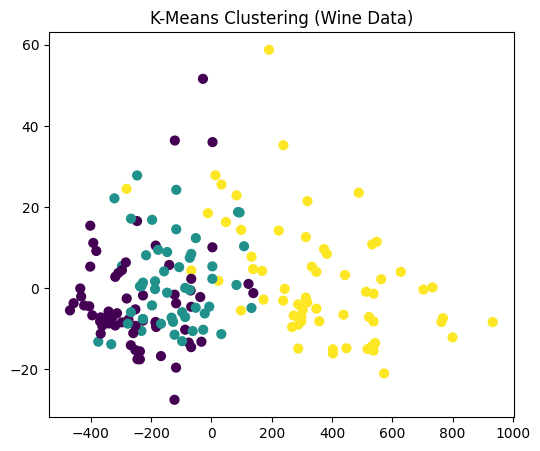

In [4]:
# 3. K-Means Clustering 

from sklearn.cluster import KMeans 
from sklearn.metrics import adjusted_rand_score, silhouette_score 
import matplotlib.pyplot as plt 

kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

print("K-Means ARI:", adjusted_rand_score(y_true, y_kmeans))
print("K-Means Silhouette:", silhouette_score(X_scaled, y_kmeans))

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans, cmap="viridis", s=40)
plt.title("K-Means Clustering (Wine Data)")
plt.show()


DBSCAN ARI: 0.0


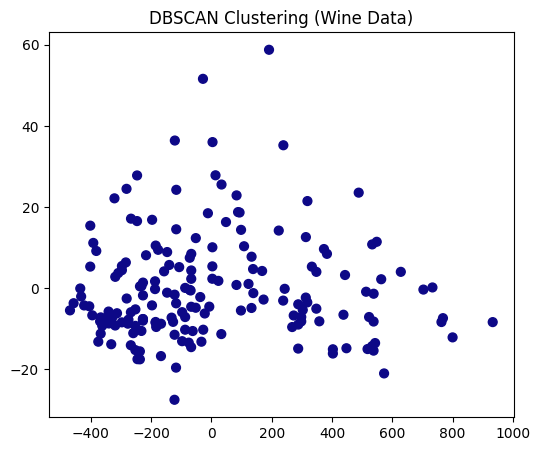

In [6]:
# 4. DBSCAN Clustering 

from sklearn.cluster import DBSCAN 

dbscan = DBSCAN(eps=1.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled) 

print("DBSCAN ARI:", adjusted_rand_score(y_true, y_dbscan))
# only compute silhouette on non-noise points 
if len(set(y_dbscan))>1 and -1 in y_dbscan:
    mask = ydbscan != -1
    print("DBSCAN Silhouette:", silhouette_score(X_scaled[mask], y_dbscan[mask]))

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_dbscan, cmap='plasma', s=40)
plt.title("DBSCAN Clustering (Wine Data)")
plt.show()


**Reflection**

- KMeans performed better on the Wine dataset. It acheived a high ARI (=0.89), meaning its clusters are well aligned with the true wine classes. DBSCAN with the chosen parameters failed to separate meaningful clusters (ARI=0.0), grouping almost all samples into a single cluster.
- K-Means requires the number of clusters to be specified. With k=3, it matched the known number of wine classes, producing good results. DBSCAN depends heavily on eps and min_samples. With a small eps it treated most points as part of one cluster. Larger values of eps may produce multiple clusters, but tuning is non-trivial and dataset-specific.
- K-Means works well when clusters are spherical and balanced but struggles with non-spherical or unevenly sized clusters. DBSCAN can detect arbitrarily shaped clusters and handle noise points, but it is 
